# MQST NMR Lab 1

#### Initialize python libraries

In [ ]:
from IPython.display import Image
import pandas as pd
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt

In [ ]:
import os
path = os.getcwd()
print(path)

/content


## Introduction

Welcome to Ensemble quantum computing.

In Nuclear Magnetic Resonance, the magnetic moment of an ensemble of nuclear spins is observed.

The density matrix of individual spins in the static magnetic field aling z-axis, and at the equilibrium state is written as:
$$\rho_0=\frac{1}{2} (\mathbb{I}+\epsilon\sigma_z)$$
where $\sigma_z$ is the third Pauli matrix, and $\epsilon$ is the polarization factor which is around $10^{-6}$ at room temperature and magnetic field strength of 7 T, for 1H spin. These have been discussed in the prelab questions and week 0 reading materials.

The idea of this lab is to become familiar with running NMR experiments, learn about the characteristics of RF pulses and the quantum control of single spin qubits, and understand the difference between $T_1$, $T_2$, and $T_2^*$. Along the way, you should become familiar with the format of the pulse program and how to report NMR data.

## Background

Please make sure that you are now very familiar with the materials selected from chapter 2-5 of the Keeler book in "NMRIntro_Keeler-ch2-5.pdf", which was assigned reading for both Pre-lab's 0 and 1 and the source of many of the prelab problems.  To summarize those sections again for you :
- Selected part of chapter 2 provides an overview of NMR spectroscopy for one and two spin systems.
- Chapter 3 goes over the vector discription of NMR which is helpful in visualising the magnetic moment vector, effect of rotation operators, and NMR detection in the rotating frame.
- Chapter 4 is an overview of signal processing and Fourier transformation.
- Chapter 5 provides a brief description of the traditional NMR instrument.

In the current setup of the NMR lab, we are using benchtop NMR instruments, which have the same building blocks as traditional spectrometers but with many functions  automated for ease of use. The material covered in Keeler Chapters 4 and 5 are not necessary for performing this weeks experiment, but being familiar with the basics of signal processing and RF electronics will pay off in the long run.

You should now be familiar with the "Pulse Programming Quickstart.pdf" guide and
be prepared to start writing pulse programs on the actual system. The documents "SpinsolveExpert - User Manual.pdf" and "Pulse Programming Guide.pdf" are the official Magritek documentation for further details and reference.

## Spectrometer calibration

1. Run the SpinSolveExpert program from the Windows tray icon or desktop shortcut.
2. Load one of the standard water samples (5% H$_2$O+ 95% D$_2$O) into a sample holder and use the depth gauge to make sure that the sample resides at the sweet spot of the NMR coil.
3. Clean up the sample tube using IPA and Load the sampleholder to the magnet
4. From the "Setup" menu in SpinSolveExpert use the "QuickShim ..." option
5. QuickShim parameters
    - Sample type: Water
    - Shim start mode: Last Expert Shim
    - Shim search mode: 1st and 2nd order
    
6. Shimming is done when the linewidth at 50% is less than 1 Hz
7. From the "Monitor" menu choose "Monitor lock and temperature" option, the temperature should be stable
8. From the "Monitor" menu choose "Find lock" option, the lock deviation should be smaller than 0.1 Hz

## Experiment #1 : Free Induction Decay (FID) Water (1H)

### Experimental parameters

1. From the "Templates" menu, make a copy of the proton FID template, "FID_1H_Template" and save it to your group's folder.

2. Open the pulse program and add the required pulse sequence to perform an FID. This is something you already determined in question 1 of the prelab.

3. For this first experiment, we start by reviewing the most important parameters and varying many of them to get a feel for what each does :
    - <font color='blue'> Transmitter channel      : 1H</font>
    - <font color='blue'> 1H Frequency [MHz]     </font>
    <br> We are looking at the NMR signal from Hydrogen nuclei. 1H is a spin 1/2 particle with a Larmor frequency of approximately 62.37 MHz in these spectrometers. The  parameter shown is that determined by the system for the current magnetic field shim values.
    - <font color='blue'>Center frequency [ppm] : 5</font>
    <br> The 1H nuclei in the water sees a local field that is slightly different from that of a "bare proton" or TMS standard sample, due to the electron shielding (chemical shift). The shift for 1H in water has been observed to be approximately equal to 4.8 ppm. So by setting the center frequency to 5 ppm we are reasonably close to the resonance condition. You can change the center frequency to be nearly on resonance and also to be far from the resonance condition and compare the experimental results.
        - Go on resonance by setting the center frequency to the frequency of the water peak from the spectral data.
        - What happens as you then increase the offset further from resonance?
        - Can you pulse outside the bandwith of the the acqusition window? Is the resulting signal reliable?
    - <font color='blue'>Pulse length [$\mu\text{s}$]      : 13 </font>
    <br> This is the pulse length, and it determines the rotation angle of the magnetization vector.
        - Try applying small rotations incrementally, how does the observable signal change?
        - Increment the pulse length and find an approximate value for a 90 degree pulse.
        - Find the length required for a 180 degree pulse, where the observable signal is closest to zero. Is the pulse length in agreement with the 90 degree pulse found in the previous step?
    - <font color='blue'>Repetition time [ms]   : 10000</font>
    <br> This value sets the time delay between the start of each scan. This time must be larger than the total data acqusition time (number of points x Dwell time) and should provide sufficient delay to allow for a full T$_1$ recovery of the spin system before another experiment is run.
    - <font color='blue'> Receiver channel      : 1H</font>
    - <font color='blue'>Number of points      : 4096</font>
    <br> This is the number of points that will be acquired during data acquisition.
    - <font color='blue'>Dwell time ($\mu\text{s}$)        : 1000</font>
    <br> This sets the time interval between datapoints. Based on the Nyquist sampling theorem, the bandwidth of the spectrum is determined by this parameter as well.
    - <font color='blue'>Minimum ppm value     : -1</font>
    - <font color='blue'>Maximum ppm value     : 7</font>
    <br>These last two values just set the limits on the frequency axis of the displayed spectrum, you can still zoom out to see the full acquired bandwidth.
    
  You may notice the peak is not necessarily positive and in an absorption mode. This may be due to the receiver phase. To calibrate the signal phase, use the phase button to the right of the data to rephase the spectra using the "p0" parameter for zeroth order and the "p1" for first order corrections. Once the signal shows an absorption curve, take note of the "p0" phase correction parameter and rerun the experiment with the "Receiver phase" set to that value. For example, if the peak is completely inverted,  p0=180 degrees. If the signal is in a positive dispersive mode, p0=-90 degrees. Note that there is also an option to autophase your experiments. Do not use this for experiment 1, but you may use this for experiments 2-6.

4. Before running an experiment, make sure that you change the experiment base path to your group's file. This is done by pressing the ellipsis next to the "experiment base-path" under the parameters list. Select Year/Month/Day then select your group's file. Once you've selected the proper path, you can add a comment to the experiment by typing it into "Current file comment" before running the experiment. This is useful for keeping track of details of the experiment being run, such as the current sample or editting specific parameters.

5. Make sure that you understand the connection between the time-domain and frequency-domain (spectral) data. Try increasing and decreasing the dwell time and number of points such that the aquisition time stays roughly the same. Observe the effect on the FID signal and spectrum quality. What do you observe and why is this occuring? Thinking of this in terms of Nyquist's theorem will help.  

  Next, select a large number of points, such as $32768$, and various values of the dwell time, from low values such as $10\,\mu\text{s}$, to high values, such as $2000\,\mu\text{s}$, and some values in between. What are the effects on the FID spectrum? How does this effect the amplitude and noise in the spectrum? You may need to increase the repetition time to allow for the longer aquisition time, so start with a high repetition time (say 60 seconds). Refer back to chapter 4 of Keeler for additional insight here.  

  General note: For shorter aquisition times, make sure that you wait long enough after each scan for the 1H nuclear spin system to relax. E.g. if your scan only takes 6 seconds, don't immediately start another one, but rather wait at least around 10 seconds longer for it to fully relax. This is due to the T1 time you will measure below in experiment 3.

### Experimental parameters (suggested starting values)

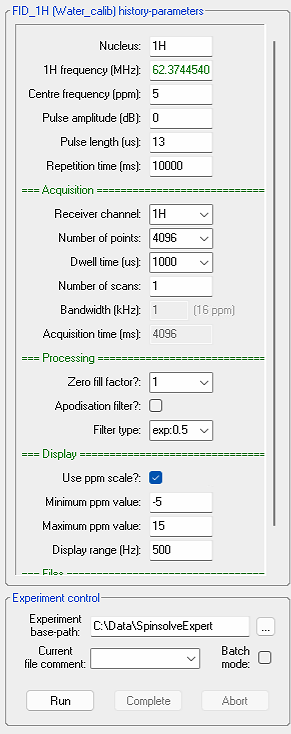

In [ ]:
Image(filename='parameters.png',  width=300, height=100)

## Experiment #2 : Proton pulse length calibration

There are 4 parameters that should be determined for applying RF pulses in NMR experiments: Pulse length and pulse amplitude determine the angle of rotation, pulse phase determines the axis of rotation, and pulse frequency determines the transmision frequency, i.e. rotating frame.
As you observed in Exp#1, arbitrary rotations can be implemented by changing the pulse length.
<br> To fine tune the proton pulse length, we need to run the pulse program with increasing pulse lengths. We can then repeat this process with narrowing step sizes to find the precise optimal pulse lengths.

1. From the "Template" menu, add a copy of the pulse length calibration template "PulseLengthCalib_1H_Template" to your group's directory.

2. Add the pulse sequence needed for the experiment into the pulse program tab.

3. Set the experimental parameters according to the last experiment.

4. The new parameters for running a sequence of experiments are "Min. pulse length", "pulse step size", and "Nr. of length steps". Start with a large step size and run 20 experiments to get a rough idea how long the pulse is. Note: The experimental program will repeat the pulse sequence you enter, while changing the pulse length starting from the minimum pulse length and increasing in steps of the pulse step size for the total number of length steps.

4. Perform an integral over the proton peak. The largest value corresponds to the $\pi/2$ pulse. Recall that the spins are aligned towards the static magnetic field, z-axis, in the equilibrium state and by applying the resonance RF pulse they are tipped toward the xy-plane. The NMR signal is the induced current of magnetic moment along the x and y axes, and it is the largest after a $\pi/2$ pulse.

5. If the results are different than the following figure, there may be parameters that should be adjusted carefully.

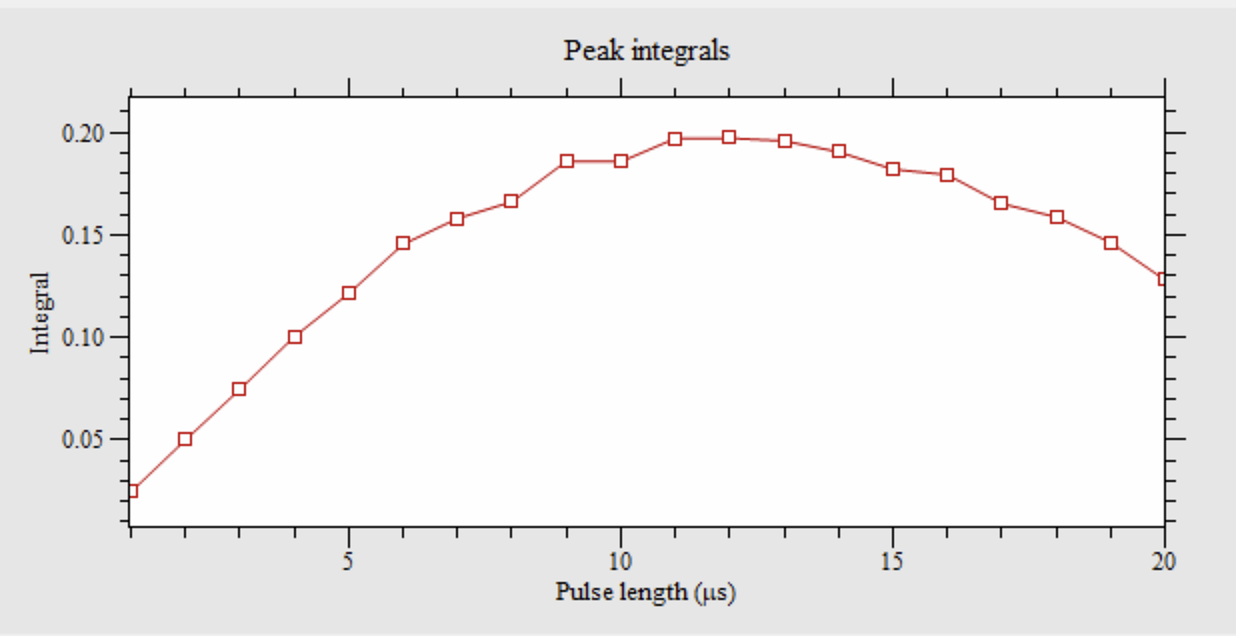

In [ ]:
Image(filename='P1_integrals.png',  width=500, height=200)

7. Finally, rerun this experiment with a smaller step size to fine tune the pulse length to $0.5$

##  Experiment #3 : $T_1$ Relaxation time, Inversion Recovery

$T_1$ relaxation accounts for relaxation of spins(qubits) to the thermal equilibrium state. In the case of spins in a large static magnetic field, the thermal equlibrium is described by the Boltzman distribution, with spins oriented along the main magnetic field, z axis, and polarization $\epsilon$. If we manipulate the spins, i.e. by applying an RF pulse in resonance with the spin frequency, $T_1$ is the characteristic time that spins take to get realigned to the z direction. The "Inversion Recovery" experiments measures this relaxation time.

From the "Templates" folder, make a copy of the "T1IR_1H_Template" experiment, which is a template of the Inversion Recovery experiment for protons that's just missing the pulse program, and save it to your group's folder.

The Experimental Control tab doesn't need to be editted. Similar to "PulseLengthCalib_1H_Template," the template will take the provided minimum repetition delay, step size, and number of steps to repeat the pulse program you write with the increasing repetition delays. By systematically increasing the repetition delay, the amplitude of recovered signal will grow, in a pattern similar to the following plot. The first data point shows the signal after a very short delay, and is very close to a fully inverted signal. To see the full extent, extend the range of repetition times. You'll need to input the inversion recovery pulse sequence you discussed in question 1 of your prelab to do the experiment.

In the parameters choose the delay min and max to cover a proper range for fitting the data.

Use the integration tool provided in the SpinsolveExpert to integrate the stack of spectra and plot the results:

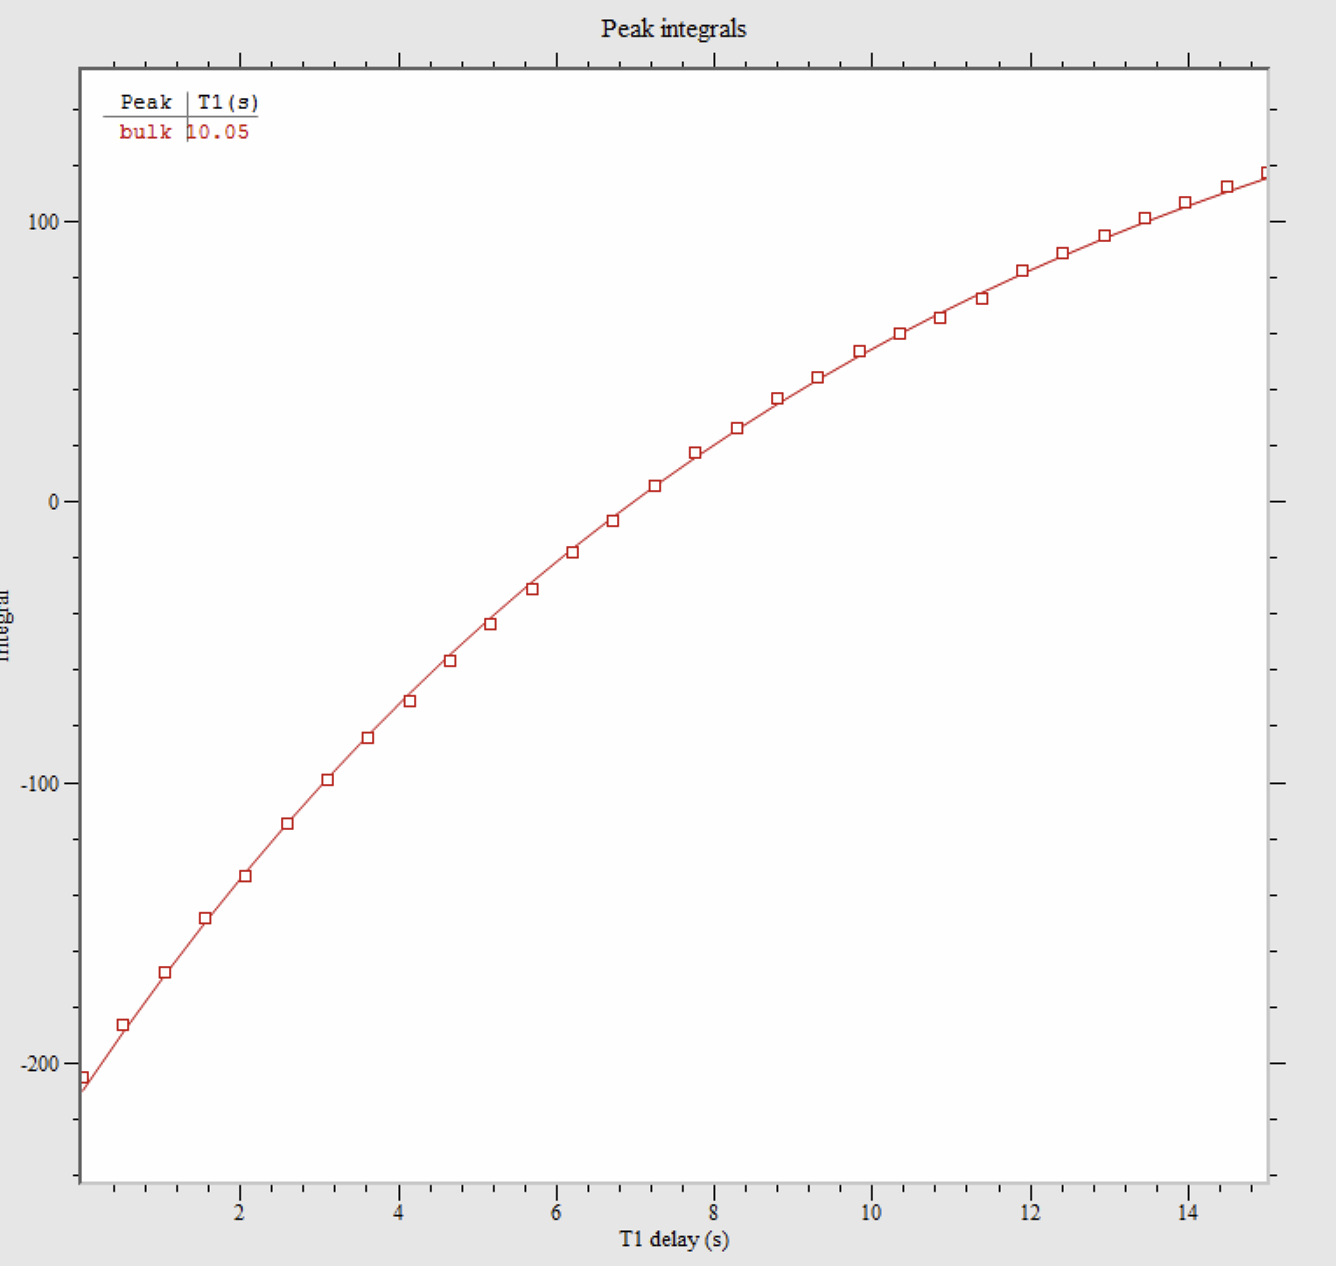

In [ ]:
Image(filename='T1_plot.png',  width=500, height=200)

Starting with this experiment, you should get into the habit of exporting data generated by Spinsolve to tabulate and process yourself.  

Here we will export the integrated peak intensities vs T1 delay time data as a ".csv" file to be plotted and analyzed:

In [ ]:
T1_water=pd.read_csv("/Users/mohamad/Library/CloudStorage/GoogleDrive-mniknam@g.ucla.edu/.shortcut-targets-by-id/1Pf2cZYo4cbO3CrmNeJrjjuBEH4wDcq7a/Ensemble QC Lab/411 Lab Development/Lab 1 - Single Qubit NMR/Water_T1_data.csv", header=None)

In [ ]:
T1_water

,0,1
0,0.001000,-205.06300
1,0.518207,-186.16400
2,1.035410,-167.82800
3,1.552620,-148.21800
4,2.069830,-133.22400
5,2.587030,-114.84600
6,3.104240,-99.03980
7,3.621450,-84.00340
8,4.138660,-70.75030
9,4.655860,-56.39810


Text(0.5, 1.0, 'Water T1')

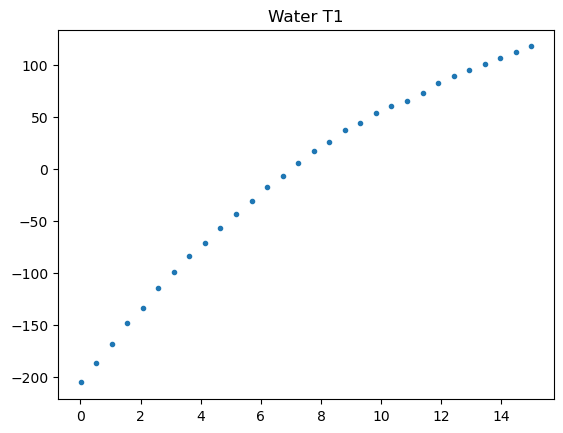

In [ ]:
xs = np.array(T1_water.iloc[:,0])
ys = np.array(T1_water.iloc[:,1])

plt.plot(xs, ys, '.')
plt.title("Water T1")

You can use your favorite curve fitting routine to work with the following function:

In [ ]:
# define the fitting function
def growExp(x, m, T1):
    return m * (1 - 2 * np.exp(-x /T1))

R² = 0.9996460481990179
T1 = 10.051684381367336 s


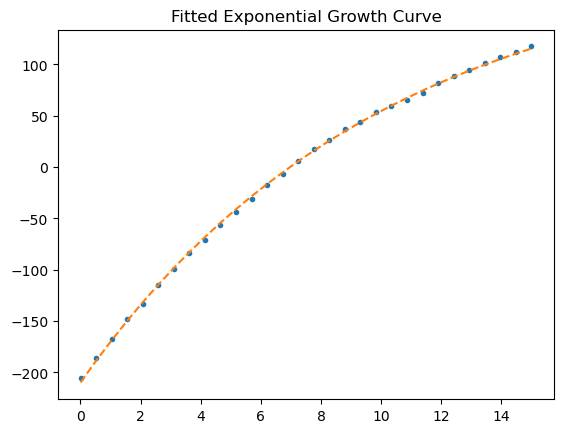

In [ ]:
# perform the fit
# Your code goes here, the results should be similar to the following plot

The result should be comparable with the number that Spinsolve reports.

Please remember that for any NMR experiment to be reliable and repeatable, typically a delay of $3T_1$ or $5T_1$ should be implemented between scans. Hence for these water samples, a minimum $30\,\text{s}$ delay is needed to ensure full rethermalization of the proton spin system.  

##  Experiment #4 : $T_1$ Relaxation time, Saturation Recovery

When the $T_1$ relaxation time is very long, the "Saturation Recovery" experiment can be used instead of the "Inversion Recovery". The idea is to apply a set of 90 degree pulses and delays to saturate the Bloch sphere, in which the magnetic moments of spins in the xy plane is initially set to zero. The saturation  pulse may be implemented using eight 90 degree pulses with delays that are as long as $T_2^*$ time. In this section, you should copy your version of the "T1IR_1H_Template" from Exp#3 and use it as a base for the saturation recovery experiment. Replace all the preparation pulses with a series of 90pulse1H and satDelays. Please recall that if you are introducing a new delay, it should be properly defined in the pulse program (.mac file) and the variable name needs to start with a "d." After a saturation pulse train, spins recover in the z direction and a detection pulse can measure the rate of this recovery. For small delays the signal amplitude should be close to zero.

##  Experiment #5 : Hahn echo experiment

In liquid state NMR, magnetic field inhomogeneities are the leading cause of dephasing error. Spins observe a distribution of fields in the xy-plane and as a result acquire phase differences resulting in the decay of the ensemble spin signal. This decay is characterized by the $T_2^*$ relaxation time. $B_0$ inhomogeneities can be corrected by shimming the field, which is why we see long lasting FIDs in the first experiment. If the shim is spoiled, the decay time dramatically decreases. To see this, repeat the "FID_1H" experiment while you intentionally spoil the shim. From the menu choose "Setup > Load Expert or User Shim". Write down the value for z shim, change it to zero, and hit "run" to load the editted shim. {Don't forget to restore this value when done!}  What is the linewidth now? You may need to adjust the Dwell time accordingly.

This fast decay of NMR signal is a result of field inhomogeneity along the z-axis, with a Hamiltonian that can be written as $\mathcal{H}_{deph}= \omega_{deph} I_z$. The effect of this Hamiltonian can be reversed with a $\pi$ pulse along the x or y axes. So if a $\pi$ pulse is applied in the middle of a delay, an echo signal is going to show up at the end of the delay, that is called the "Hahn echo".

Save a copy of the "HahnEcho_1H_Template" to your group's directory. Insert the pulse sequence to perform a Hahn Echo experiment (aka spin echo) that you wrote in the prelab assignment.  Now, when running the experiment, remember to choose an echo time that exceeds the decay time of the FID. Do you see the spin echo? Is it at the right time? Again, remember to restore the z shim back to its original value after performing this experiment.

##  Experiment #6 : Pulse Amplitude Calibration

One of the parameters defining the rotation angle of an RF pulse is its amplitude, if we assume that the pulse has a square shape, the total power transmitted to the spins is proportional to the Area of the square pulse. Pulse amplitude is determined by the gain of the power amplifier, denoted as "pulse amplitude (dB)" in the experimental parameters list. In this instrument pulse amplitude is a 14 bit number going from -85 dB to 0 dB. So the maximum power is at zero dB, which is a few watts.
The task here is to find a relation between pulse length and pulse amplitude by running a sequence of experiments with a fixed pulse length and variable pulse amplitudes. You can start with the "PulseLengthCalib" experiment you wrote in Exp#2 and modify the pulse program to vary the "pulseAmplitude" instead of the "pulseLength".

Here are a few points that you may find helpful:
- make a new copy of the experiment, e.g. "PulseAmplitudeCalib", and edit the pulse program.
- Add parameters such as "minPulseAmplitude", "Amplitudestepsize", and  "nrAmplitudesteps" to the "interface list."
- Modify the Relationships to reflect the new parameters.
- change the variable from "d90H" to the name of the pulse amplitude variable.
- Modify the pulse sequence
- Switch to Experiment control and modify the section called "Calculate the pulse length" such that it reflects steps for increments  of pulse amplitude.
- Most importantly, in each scan, the incremented pulse amplitude should be sent to the spectrometer. To do that, modify the command with: "ppList = ucsRun:setPPDelay(...)" to change the pulse amplitude "ppList = ucsRun:setPPAmplitude(...)"